# Initial Dataset Observations

- Total Records: 318,438
- Total Features: 18

## Missing Values
- Bed Grade: 113
- City_Code_Patient: 4,532

## Duplicate Records
- No duplicate records found.

## Data Types
- Integer: 6
- Float: 3
- Object: 9

## Initial Conclusion
The dataset is clean overall, with only two features containing missing values. No duplicate records were found. The dataset is suitable for exploratory data analysis and machine learning after appropriate preprocessing.

In [9]:
import pandas as pd
import numpy as np


In [10]:
df = pd.read_csv("../data/raw/train_data.csv")
df.duplicated().sum()

np.int64(0)

In [11]:
df_clean = df.copy()

In [24]:
missing_percentage=(df_clean.isnull().sum() / len(df_clean))* 100
missing_percentage.sort_values(ascending=False)

City_Code_Patient                    1.423197
Bed Grade                            0.035486
Hospital_code                        0.000000
case_id                              0.000000
Hospital_region_code                 0.000000
Hospital_type_code                   0.000000
Available Extra Rooms in Hospital    0.000000
Department                           0.000000
Ward_Type                            0.000000
City_Code_Hospital                   0.000000
Ward_Facility_Code                   0.000000
patientid                            0.000000
Type of Admission                    0.000000
Severity of Illness                  0.000000
Visitors with Patient                0.000000
Age                                  0.000000
Admission_Deposit                    0.000000
Stay                                 0.000000
dtype: float64

In [12]:
df_clean["Bed Grade"] = df_clean["Bed Grade"].fillna(df_clean["Bed Grade"].mode()[0])
df_clean["City_Code_Patient"] = df_clean["City_Code_Patient"].fillna(
    df_clean["City_Code_Patient"].mode()[0]
)

In [27]:
df_clean.isnull().sum()
df_clean.to_csv("../data/processed/cleaned_train_data.csv",index=False)

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [15]:
print(df_clean.shape)
df_clean.nunique()

(318438, 18)


case_id                              318438
Hospital_code                            32
Hospital_type_code                        7
City_Code_Hospital                       11
Hospital_region_code                      3
Available Extra Rooms in Hospital        18
Department                                5
Ward_Type                                 6
Ward_Facility_Code                        6
Bed Grade                                 4
patientid                             92017
City_Code_Patient                        37
Type of Admission                         3
Severity of Illness                       3
Visitors with Patient                    28
Age                                      10
Admission_Deposit                      7300
Stay                                     11
dtype: int64

In [25]:
df_clean["Department"].unique()
df_clean["Hospital_type_code"].unique()
df_clean["Hospital_region_code"].unique()
df_clean["Ward_Type"].unique()
df_clean["Severity of Illness"].unique()
df_clean["Type of Admission"].unique()

<StringArray>
['Emergency', 'Trauma', 'Urgent']
Length: 3, dtype: str

In [26]:
df_clean["Stay"].value_counts()

Stay
21-30                 87491
11-20                 78139
31-40                 55159
51-60                 35018
0-10                  23604
41-50                 11743
71-80                 10254
More than 100 Days     6683
81-90                  4838
91-100                 2765
61-70                  2744
Name: count, dtype: int64

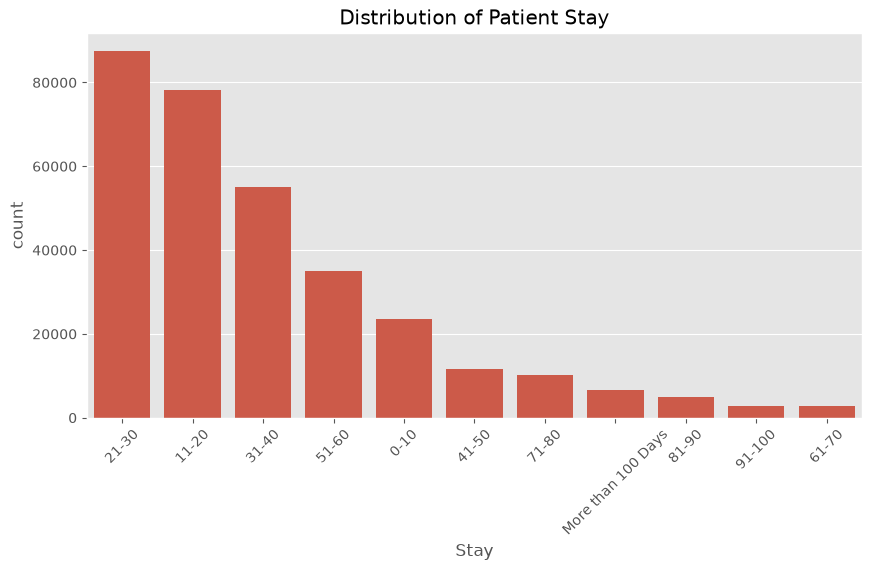

In [28]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df_clean,
    x="Stay",
    order=df_clean["Stay"].value_counts().index
)

plt.xticks(rotation=45)
plt.title("Distribution of Patient Stay")
plt.show()


## Observation
21-30 max 61-70 least

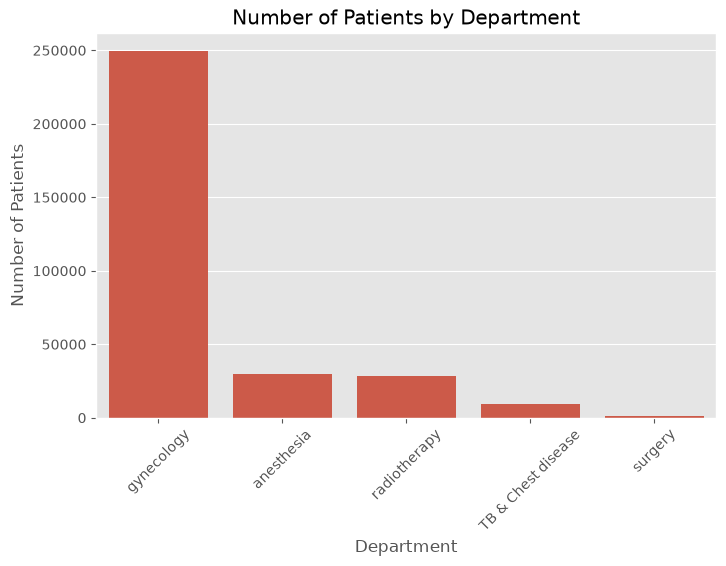

In [32]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_clean,
    x="Department",
    order=df_clean["Department"].value_counts().index
)

plt.xticks(rotation=45)
plt.title("Number of Patients by Department")
plt.xlabel("Department")
plt.ylabel("Number of Patients")

plt.show()

## Observation
gynecology has majority no of patients

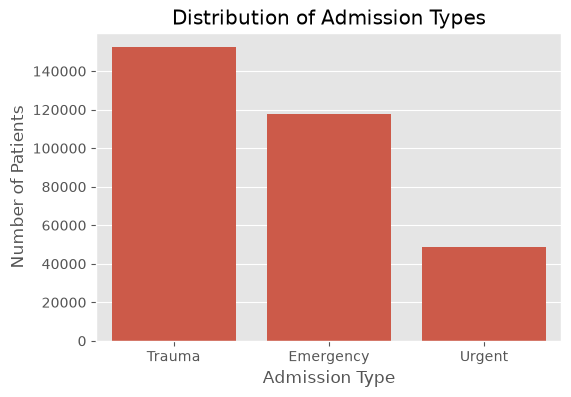

In [31]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df_clean,
    x="Type of Admission",
    order=df_clean["Type of Admission"].value_counts().index
)

plt.title("Distribution of Admission Types")
plt.xlabel("Admission Type")
plt.ylabel("Number of Patients")

plt.show()

## Observation
Trauma>Emergency>Urgent